In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
import warnings
import time
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats

c:\Users\windows\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = pd.read_csv('C:\\Users\\windows\\.cache\\kagglehub\\datasets\\mubashirrahim\\wind-power-generation-data-forecasting\\versions\\1\\Location1.csv')
df

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793
...,...,...,...,...,...,...,...,...,...,...
43795,2021-12-31 19:00:00,34.1,94,32.5,1.00,1.91,53,137,2.5,0.1796
43796,2021-12-31 20:00:00,34.8,94,33.4,2.52,4.30,56,72,4.8,0.2066
43797,2021-12-31 21:00:00,34.1,95,33.0,1.10,1.84,360,45,4.3,0.2336
43798,2021-12-31 22:00:00,34.4,96,33.5,2.40,4.62,45,51,4.2,0.2606


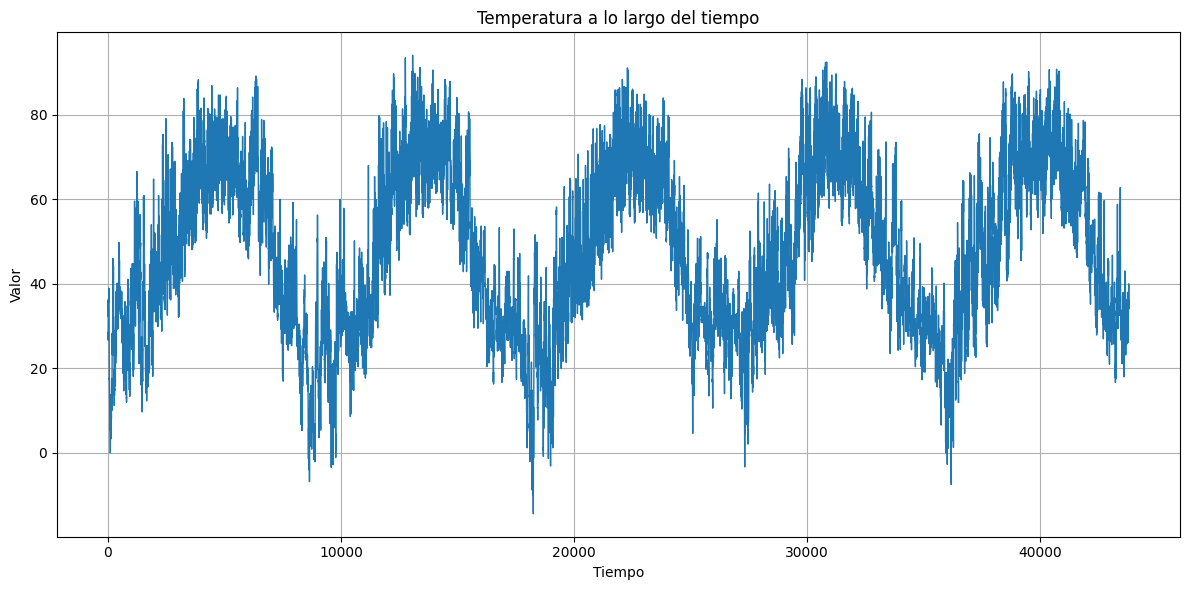


Serie visualizada correctamente.


In [6]:
df = pd.read_csv('C:\\Users\\windows\\.cache\\kagglehub\\datasets\\mubashirrahim\\wind-power-generation-data-forecasting\\versions\\1\\Location1.csv')
df = df[['temperature_2m','Time']]
df["Date"] = pd.to_datetime(df["Time"])
df.set_index("Time", inplace=True)
df.rename(columns={"temperature_2m" : "value"}, inplace = True)
# Creamos un índice para visualizar la serie
df.index = pd.RangeIndex(start=0, stop=len(df), step=1)

# Visualizar
plt.figure(figsize=(12,6))
plt.plot(df["value"], linewidth=1)
plt.title("Temperatura a lo largo del tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSerie visualizada correctamente.")

## Valores perdidos

In [7]:
df.isna().value_counts()

value  Date 
False  False    43800
Name: count, dtype: int64

No tiene valores perdidos la serie, se continua al siguiente inciso.

## Transformaciones

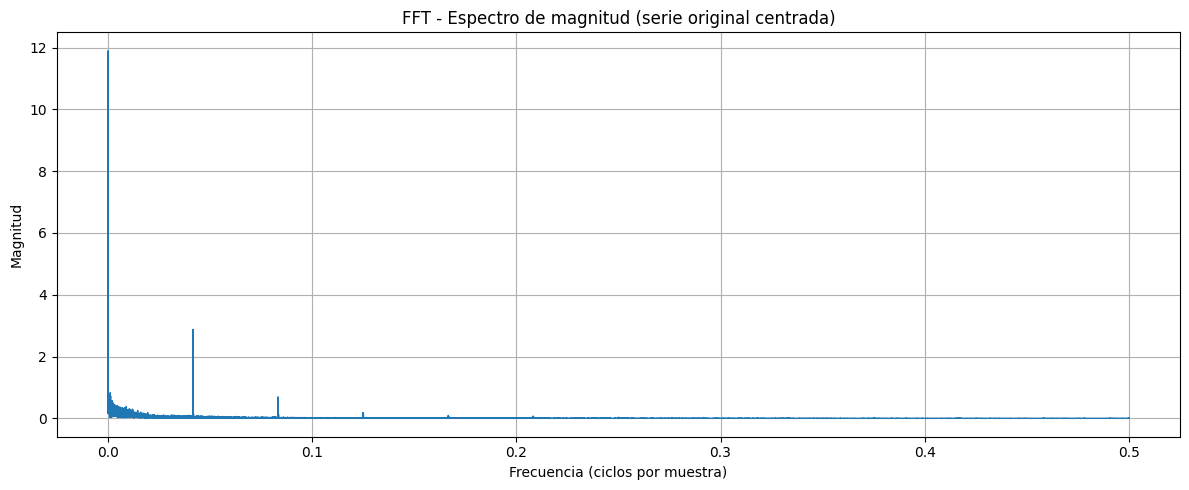


Top frecuencias dominantes (serie original centrada):
1) f=0.000114 -> periodo≈8760.00 muestras, magnitud=11.900503
2) f=0.041667 -> periodo≈24.00 muestras, magnitud=2.878176
3) f=0.000023 -> periodo≈43800.00 muestras, magnitud=0.894458
4) f=0.001164 -> periodo≈858.82 muestras, magnitud=0.832812
5) f=0.000457 -> periodo≈2190.00 muestras, magnitud=0.753522


In [9]:
# ============================================
def fft_spectrum(x: np.ndarray, dt: float = 1.0):
    """
    Retorna frecuencias positivas y magnitud normalizada del espectro FFT.
    dt: intervalo de muestreo (si es 1 muestra por unidad de tiempo, dt=1.0)
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)  # centrar
    n = len(x)

    X = np.fft.rfft(x)                 # FFT real (solo frecuencias >= 0)
    freqs = np.fft.rfftfreq(n, d=dt)   # vector de frecuencias
    mag = np.abs(X) / n                # magnitud normalizada

    return freqs, mag

# FFT sobre serie original centrada
freqs, mag = fft_spectrum(df['value'].values, dt=1.0)

# Para evitar el pico en frecuencia 0 (DC) al graficar, lo removemos visualmente
mask_nonzero = freqs > 0

# 7) Gráficas FFT
# ============================================
plt.figure(figsize=(12, 5))
plt.plot(freqs[mask_nonzero], mag[mask_nonzero], linewidth=1)
plt.title("FFT - Espectro de magnitud (serie original centrada)")
plt.xlabel("Frecuencia (ciclos por muestra)")
plt.ylabel("Magnitud")
plt.grid(True)
plt.tight_layout()
plt.show()

# (Opcional) Mostrar los periodos dominantes aproximados (top 5)
# Evitamos freqs = 0
top_k = 5
idx_sorted = np.argsort(mag[mask_nonzero])[::-1][:top_k]
top_freqs = freqs[mask_nonzero][idx_sorted]
top_mags = mag[mask_nonzero][idx_sorted]
top_periods = 1 / top_freqs

print("\nTop frecuencias dominantes (serie original centrada):")
for i, (f, m, p) in enumerate(zip(top_freqs, top_mags, top_periods), 1):
    print(f"{i}) f={f:.6f} -> periodo≈{p:.2f} muestras, magnitud={m:.6f}")